In [ ]:
1

In [ ]:
import pandas as pd

df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("Shape:", df.shape)

df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
print(f"Shape: {df.shape}")


Shape: (7043, 21)


In [3]:
# Display basic information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
# Display all column names in the dataset
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [5]:
# Generate statistical summary of numerical columns
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
# Check missing values in each column
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
# Count blank spaces in TotalCharges column
(df['TotalCharges'] == ' ').sum()

np.int64(11)

In [8]:
# Convert TotalCharges column from object to numeric
# Invalid values will become NaN
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

# Check null values after conversion
df['TotalCharges'].isnull().sum()

np.int64(11)

In [9]:
# Fill missing values in TotalCharges with median value
df['TotalCharges'].fillna(
    df['TotalCharges'].median(),
    inplace=True
)

# Verify all missing values are handled
df.isnull().sum()

C:\Users\aateq\AppData\Local\Temp\ipykernel_18356\878225097.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [10]:
# Display churn distribution count
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [11]:
# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

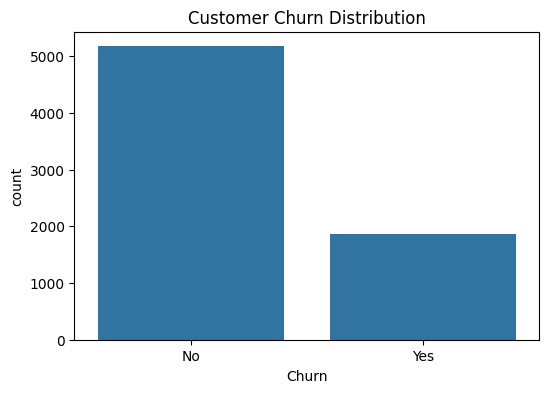

In [12]:
# Plot churn distribution using countplot
plt.figure(figsize=(6,4))

sns.countplot(
    x='Churn',
    data=df
)

plt.title('Customer Churn Distribution')

plt.savefig('../reports/churn_distribution_bar.png')

plt.show()

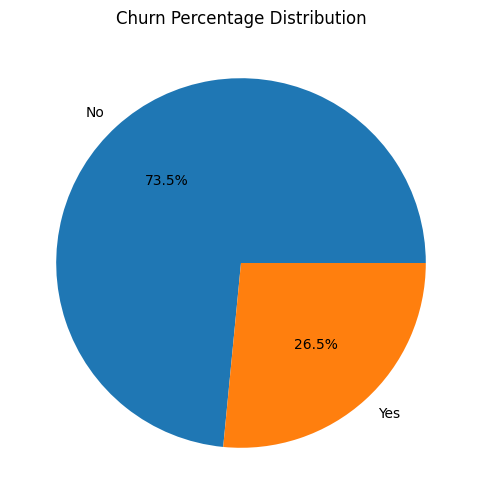

In [13]:
# Plot churn distribution using pie chart
churn_counts = df['Churn'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    churn_counts,
    labels=churn_counts.index,
    autopct='%1.1f%%'
)

plt.title('Churn Percentage Distribution')

plt.savefig('../reports/churn_distribution_pie.png')

plt.show()

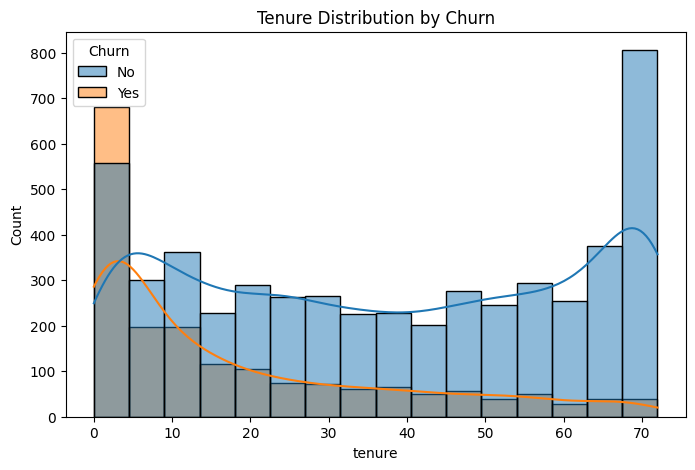

In [14]:
# Plot distribution of tenure based on churn
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='tenure',
    hue='Churn',
    kde=True
)

plt.title('Tenure Distribution by Churn')

plt.savefig('../reports/tenure_distribution.png')

plt.show()

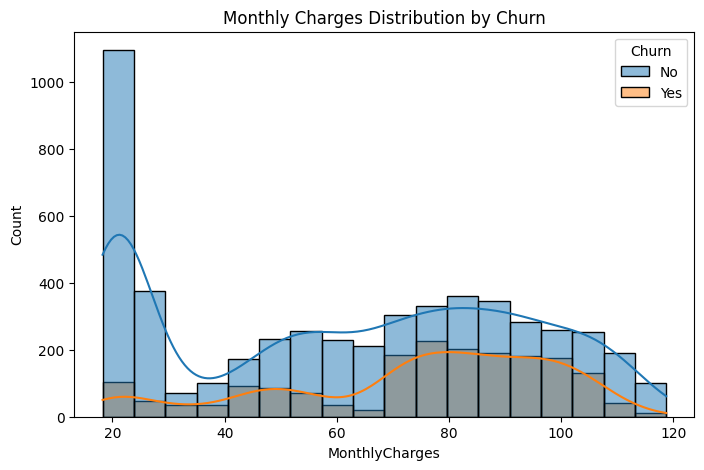

In [15]:
# Plot distribution of MonthlyCharges based on churn
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='MonthlyCharges',
    hue='Churn',
    kde=True
)

plt.title('Monthly Charges Distribution by Churn')

plt.savefig('../reports/monthlycharges_distribution.png')

plt.show()

In [16]:
# Convert Churn column into numeric values for correlation
df['Churn_Numeric'] = df['Churn'].map({
    'Yes': 1,
    'No': 0
})

In [17]:
# Create correlation matrix
corr_matrix = df[
    ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_Numeric']
].corr()

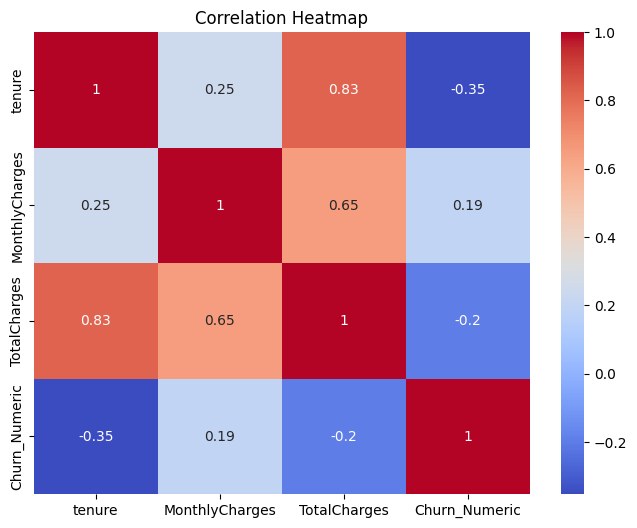

In [18]:
# Plot correlation heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.savefig('../reports/correlation_heatmap.png')

plt.show()

## Business Insight 1

Customers with month-to-month contracts have a significantly higher churn rate compared to customers with long-term contracts.

## Business Insight 2

Customers with higher monthly charges are more likely to churn.

## Business Insight 3

Customers with low tenure tend to churn more frequently than long-term customers.

## Business Insight 4

The dataset is imbalanced because the number of non-churn customers is much higher than churn customers.

## Business Insight 5

Tenure has a negative correlation with churn, meaning loyal customers are less likely to leave the company.

# Churn Analysis by Contract Type

This analysis examines how customer churn varies across different contract types.

Business Objective:
- Identify which contract type has the highest churn rate.
- Understand customer retention patterns.
- Generate actionable business insights for reducing churn.

In [19]:
# Create a churn percentage table for each contract type

# Cross-tabulation between Contract and Churn
contract_churn = pd.crosstab(
    df["Contract"],      # Contract categories
    df["Churn"],         # Churn labels
    normalize="index"    # Convert counts into row percentages
) * 100                 # Convert proportions to percentages

# Display churn percentages
contract_churn.round(2)

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


# Contract Type vs Churn Rate Visualization

This chart compares churn percentages across different contract categories.

Expected Observation:
- Month-to-month customers usually have the highest churn.
- Long-term contracts generally have lower churn rates.

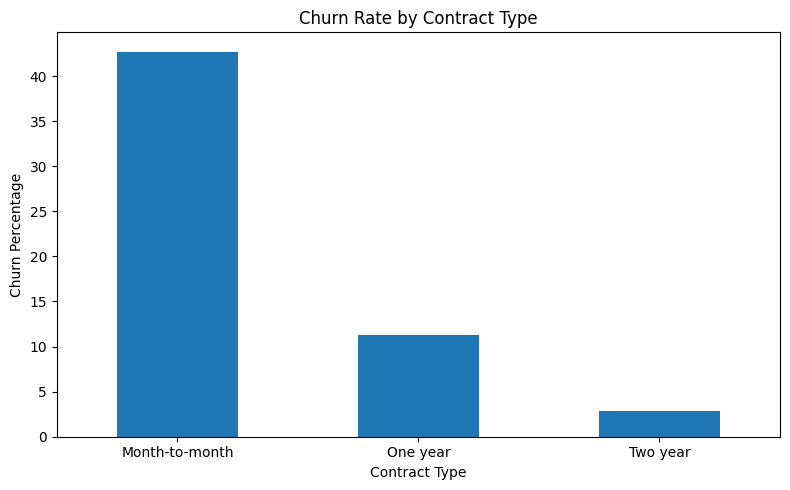

In [20]:
# Import plotting library
import matplotlib.pyplot as plt

# Create figure
plt.figure(figsize=(8, 5))

# Plot churn percentages
contract_churn["Yes"].plot(
    kind="bar"
)

# Add chart title
plt.title("Churn Rate by Contract Type")

# Label x-axis
plt.xlabel("Contract Type")

# Label y-axis
plt.ylabel("Churn Percentage")

# Rotate labels for readability
plt.xticks(rotation=0)

# Adjust layout
plt.tight_layout()

# Save chart into reports folder
plt.savefig(
    "../reports/contract_churn.png"
)

# Display chart
plt.show()

# Business Insight: Contract Type

Observation:
- Customers with month-to-month contracts exhibit the highest churn rate.
- Customers with one-year and two-year contracts are significantly more loyal.

Business Recommendation:
- Encourage customers to move from month-to-month plans to longer-term contracts through discounts, loyalty rewards, or bundled offers.

# Churn Analysis by Payment Method

This analysis examines how customer churn varies across different payment methods.

Business Objective:
- Identify payment methods associated with higher churn.
- Understand customer payment behavior.
- Discover opportunities to improve customer retention.

In [21]:
# Create churn percentage table for each payment method

payment_churn = pd.crosstab(
    df["PaymentMethod"],      # Payment method categories
    df["Churn"],              # Churn labels
    normalize="index"         # Convert counts to percentages
) * 100

# Display churn percentages
payment_churn.round(2)

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24
Electronic check,54.71,45.29
Mailed check,80.89,19.11


# Payment Method vs Churn Rate Visualization

This visualization compares churn percentages across payment methods.

Expected Observation:
- Some payment methods may show noticeably higher churn rates.
- Automatic payment methods often have better customer retention.

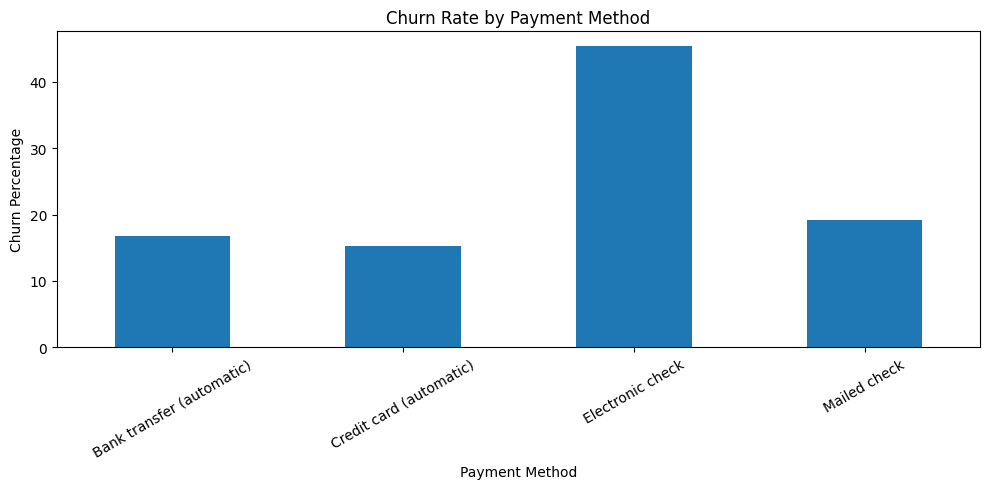

In [22]:
# Create figure for payment method churn analysis

plt.figure(figsize=(10, 5))

# Plot churn percentage for each payment method
payment_churn["Yes"].plot(
    kind="bar"
)

# Add chart title
plt.title("Churn Rate by Payment Method")

# Label x-axis
plt.xlabel("Payment Method")

# Label y-axis
plt.ylabel("Churn Percentage")

# Rotate labels for better readability
plt.xticks(rotation=30)

# Adjust layout
plt.tight_layout()

# Save chart to reports folder
plt.savefig(
    "../reports/payment_method_churn.png"
)

# Display chart
plt.show()

# Business Insight: Payment Method

## Observation

- Customers using Electronic Check show the highest churn rate.
- Customers using Automatic Bank Transfer and Automatic Credit Card payments have significantly lower churn rates.
- Mailed Check customers have a moderate churn rate.

## Business Recommendation

- Encourage customers to switch from Electronic Check to Automatic Payment methods.
- Offer incentives such as cashback, discounts, or reward points for enrolling in automatic payment plans.
- Investigate whether Electronic Check users experience payment-related inconvenience or service dissatisfaction.

# Churn Analysis by Internet Service

This analysis examines how churn varies across different internet service types.

Business Objective:
- Identify which internet service category experiences the highest churn.
- Understand whether service type influences customer retention.
- Discover opportunities for service improvement.

In [23]:
# Create churn percentage table for each internet service type

internet_churn = pd.crosstab(
    df["InternetService"],    # Internet service categories
    df["Churn"],             # Churn labels
    normalize="index"        # Convert counts into percentages
) * 100

# Display churn percentages
internet_churn.round(2)

Churn,No,Yes
InternetService,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40


# Internet Service vs Churn Rate Visualization

This visualization compares churn percentages across different internet service categories.

Expected Observation:
- Fiber optic customers often exhibit higher churn rates.
- Service quality and pricing may influence customer retention.

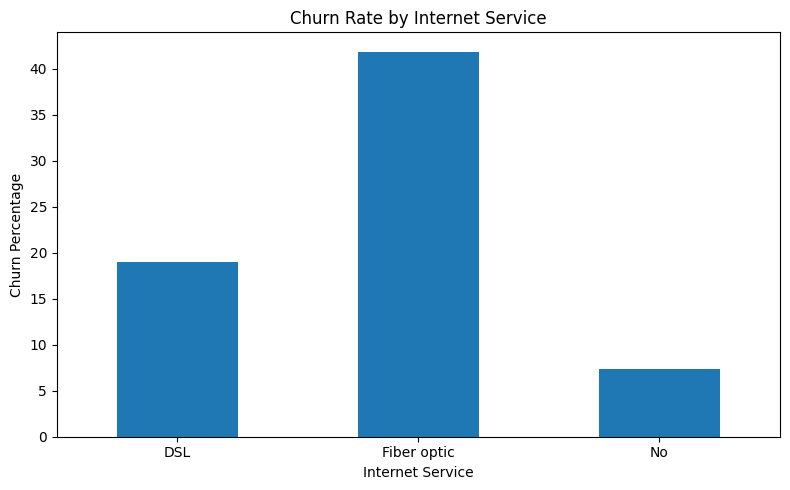

In [24]:
# Create figure

plt.figure(figsize=(8, 5))

# Plot churn percentages by internet service type

internet_churn["Yes"].plot(
    kind="bar"
)

# Add chart title

plt.title("Churn Rate by Internet Service")

# Label x-axis

plt.xlabel("Internet Service")

# Label y-axis

plt.ylabel("Churn Percentage")

# Rotate labels

plt.xticks(rotation=0)

# Adjust layout

plt.tight_layout()

# Save chart

plt.savefig(
    "../reports/internet_service_churn.png"
)

# Display chart

plt.show()

# Business Insight: Internet Service

## Observation

- Customers using Fiber Optic internet service have the highest churn rate.
- DSL customers show a significantly lower churn rate.
- Customers without internet service have the lowest churn rate.

## Business Recommendation

- Investigate why Fiber Optic customers are leaving at a higher rate.
- Analyze pricing, service quality, network reliability, and customer support issues associated with Fiber Optic plans.
- Design targeted retention campaigns for Fiber Optic customers.
- Offer loyalty discounts and service upgrades to high-risk Fiber Optic users.

# Churn Analysis by Senior Citizen Status

This analysis examines whether churn behavior differs between senior citizens and non-senior citizens.

Business Objective:
- Determine whether age group influences churn.
- Identify high-risk customer segments.
- Develop targeted retention strategies.

In [25]:
# Create churn percentage table for senior citizen status

senior_churn = pd.crosstab(
    df["SeniorCitizen"],     # Senior citizen indicator
    df["Churn"],             # Churn labels
    normalize="index"        # Convert counts into percentages
) * 100

# Display churn percentages

senior_churn.round(2)

Churn,No,Yes
SeniorCitizen,,
0,76.39,23.61
1,58.32,41.68


# Senior Citizen vs Churn Rate Visualization

This visualization compares churn percentages between senior citizens and non-senior citizens.

Expected Observation:
- One group may demonstrate a noticeably higher churn rate.
- This information can help create targeted customer retention programs.

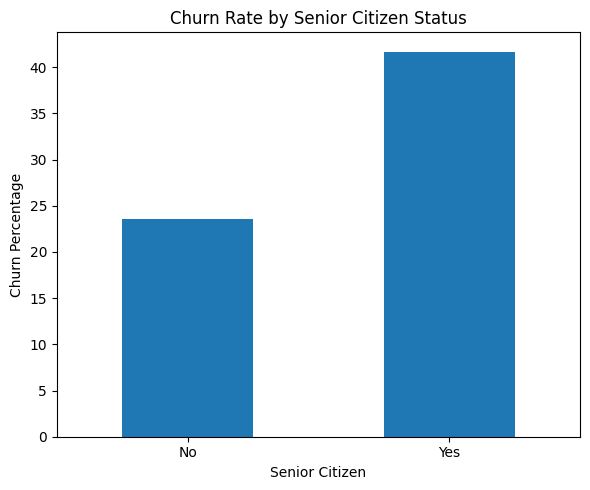

In [26]:
# Create figure

plt.figure(figsize=(6, 5))

# Plot churn percentage

senior_churn["Yes"].plot(
    kind="bar"
)

# Add title

plt.title("Churn Rate by Senior Citizen Status")

# Label x-axis

plt.xlabel("Senior Citizen")

# Label y-axis

plt.ylabel("Churn Percentage")

# Replace numeric labels with readable labels

plt.xticks(
    ticks=[0, 1],
    labels=["No", "Yes"],
    rotation=0
)

# Adjust layout

plt.tight_layout()

# Save chart

plt.savefig(
    "../reports/senior_citizen_churn.png"
)

# Display chart

plt.show()

# Business Insight: Senior Citizen Status

## Observation

- Senior Citizens exhibit a significantly higher churn rate than non-senior citizens.
- The churn rate among senior citizens is approximately 42%, compared to approximately 24% for non-senior customers.

## Business Recommendation

- Develop specialized retention programs for senior citizens.
- Improve customer support accessibility and service guidance.
- Offer loyalty benefits and simplified service plans tailored to senior customers.
- Conduct customer feedback surveys to better understand their needs and concerns.

# Executive Summary of Exploratory Data Analysis

This section summarizes the major findings discovered during Exploratory Data Analysis.

The objective is to identify the primary factors influencing customer churn and provide actionable business recommendations.

# Top Churn Drivers Identified

## 1. Contract Type

Customers with month-to-month contracts exhibit the highest churn rate.

## 2. Internet Service

Fiber Optic customers demonstrate the highest churn rate among all internet service categories.

## 3. Payment Method

Customers using Electronic Check show significantly higher churn rates than customers using automatic payment methods.

## 4. Customer Tenure

Customers with shorter tenure are more likely to churn than long-term customers.

## 5. Monthly Charges

Customers with higher monthly charges tend to churn more frequently.

## 6. Senior Citizen Status

Senior citizens exhibit noticeably higher churn rates than non-senior customers.

# High-Risk Customer Segments

The following customer groups are considered high-risk:

- Month-to-Month Contract Customers
- Fiber Optic Internet Users
- Electronic Check Users
- Senior Citizens
- Customers with High Monthly Charges
- Customers with Low Tenure

# Low-Risk Customer Segments

The following customer groups demonstrate strong retention:

- Two-Year Contract Customers
- One-Year Contract Customers
- Automatic Payment Users
- Long-Term Customers
- Customers Without Internet Service

# Business Recommendations

## Contract Strategy

Encourage customers to migrate from month-to-month contracts to longer-term plans through discounts and loyalty incentives.

## Service Improvement

Investigate customer dissatisfaction among Fiber Optic users and improve service quality.

## Payment Optimization

Promote automatic payment methods to reduce churn.

## Customer Retention

Develop targeted retention campaigns for high-risk customer segments.

## Senior Citizen Programs

Create customer support initiatives specifically designed for senior citizens.

## Loyalty Programs

Reward long-term customers and incentivize customer engagement.

# Conclusion

Exploratory Data Analysis identified several strong predictors of customer churn.

Contract type, internet service type, payment method, tenure, monthly charges, and senior citizen status all demonstrate significant relationships with churn behavior.

These findings will guide feature engineering, preprocessing, and predictive model development in subsequent stages of the project.